In [1]:
# CELL 1: Imports
import os
import numpy as np
import pandas as pd
import librosa
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

# CELL 2: Data path and common files (matching YAMNET logic)
data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)
wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt", "") for f in txt_files])
common_files = list(wav_set.intersection(txt_set))
print(f"Usable files: {len(common_files)}")

train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files   = train_test_split(train_files, test_size=0.2, random_state=42)

print(f"Train files: {len(train_files)} | Val files: {len(val_files)} | Test files: {len(test_files)}")



Usable files: 920
Train files: 588 | Val files: 148 | Test files: 184


In [2]:
def add_noise(signal, noise_factor=0.005):
    noise = np.random.randn(len(signal))
    return signal + noise_factor * noise

def time_shift(signal, shift_max=0.2):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(signal))
    return np.roll(signal, shift)

def time_stretch(signal, rate=0.9):
    return librosa.effects.time_stretch(signal, rate)

def pitch_shift(signal, sr=16000, n_steps=1):
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=n_steps)

def augment_signal(signal, sr=16000):
    augmented = []
    augmented.append(signal)                     # original
    augmented.append(add_noise(signal))          # noise
    augmented.append(time_shift(signal))         # shift
    try:
        augmented.append(time_stretch(signal, rate=np.random.uniform(0.9, 1.1)))
    except:
        pass
    try:
        augmented.append(pitch_shift(signal, sr, n_steps=np.random.uniform(-1,1)))
    except:
        pass
    return augmented



In [3]:
def get_label(crackle, wheeze):
    if crackle == 0 and wheeze == 0: return 0
    elif crackle == 1 and wheeze == 0: return 1
    elif crackle == 0 and wheeze == 1: return 2
    else: return 3

def extract_features(audio_slice, sr):
    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio_slice, sr=sr, n_mfcc=40)
    # Delta & delta-delta
    width_val = min(7, mfccs.shape[1] if mfccs.shape[1] % 2 != 0 else mfccs.shape[1] - 1)
    if width_val >= 3:
        delta_mfccs = librosa.feature.delta(mfccs, width=width_val)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2, width=width_val)
    else:
        delta_mfccs = np.zeros_like(mfccs)
        delta2_mfccs = np.zeros_like(mfccs)
    # Statistics
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std  = np.std(mfccs.T, axis=0)
    delta_mean = np.mean(delta_mfccs.T, axis=0)
    delta_std  = np.std(delta_mfccs.T, axis=0)
    delta2_mean = np.mean(delta2_mfccs.T, axis=0)
    delta2_std  = np.std(delta2_mfccs.T, axis=0)
    return np.hstack([mfccs_mean, mfccs_std, delta_mean, delta_std, delta2_mean, delta2_std])



In [4]:
def build_segments(file_list, augment=False):
    """Extract segments and their features. If augment=True, apply augmentation to each segment."""
    X = []
    y = []
    sr = 16000
    for file in tqdm(file_list, desc="Processing files"):
        wav_file = os.path.join(data_path, file + '.wav')
        txt_file = os.path.join(data_path, file + '.txt')
        if not os.path.exists(wav_file) or not os.path.exists(txt_file):
            continue
        audio, sr = librosa.load(wav_file, sr=sr)
        annotations = pd.read_csv(txt_file, sep='\t', names=['start', 'end', 'crackle', 'wheeze'])
        for _, row in annotations.iterrows():
            start = int(row['start'] * sr)
            end   = int(row['end'] * sr)
            segment = audio[start:end]
            if len(segment) < 1000:          # Match YAMNET threshold
                continue
            label = get_label(row['crackle'], row['wheeze'])
            if augment:
                augmented_segments = augment_signal(segment, sr)
                for aug_seg in augmented_segments:
                    # Ensure length >= 1000 after augmentation (rarely needed)
                    if len(aug_seg) >= 1000:
                        X.append(extract_features(aug_seg, sr))
                        y.append(label)
            else:
                X.append(extract_features(segment, sr))
                y.append(label)
    return np.array(X), np.array(y)

In [5]:
print("Building training set with augmentation...")
X_train, y_train = build_segments(train_files, augment=True)
print(f"Train features shape: {X_train.shape}")

print("Building validation set...")
X_val, y_val = build_segments(val_files, augment=False)
print(f"Val features shape: {X_val.shape}")

print("Building test set...")
X_test, y_test = build_segments(test_files, augment=False)
print(f"Test features shape: {X_test.shape}")

Building training set with augmentation...


Processing files: 100%|██████████| 588/588 [04:36<00:00,  2.13it/s]


Train features shape: (17912, 240)
Building validation set...


Processing files: 100%|██████████| 148/148 [00:17<00:00,  8.65it/s]


Val features shape: (1107, 240)
Building test set...


Processing files: 100%|██████████| 184/184 [00:20<00:00,  8.99it/s]

Test features shape: (1313, 240)


In [6]:
# CELL 6: Train LightGBM with regularized hyperparameters (same as original)
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_estimators=400,
    learning_rate=0.0001,
    max_depth=5,
    num_leaves=31,
    min_child_samples=30,
    class_weight='balanced',
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.5,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
)
print("Training finished.")

Training LightGBM...
Training finished.


RESULTS
Accuracy:      0.5133
Macro F1:      0.4334
Weighted F1:   0.5267
Precision:     0.5524
Recall:        0.5133
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

      Normal       0.69      0.54      0.60       634
     Crackle       0.55      0.59      0.57       407
      Wheeze       0.24      0.31      0.27       160
        Both       0.24      0.36      0.28       112

    accuracy                           0.51      1313
   macro avg       0.43      0.45      0.43      1313
weighted avg       0.55      0.51      0.53      1313



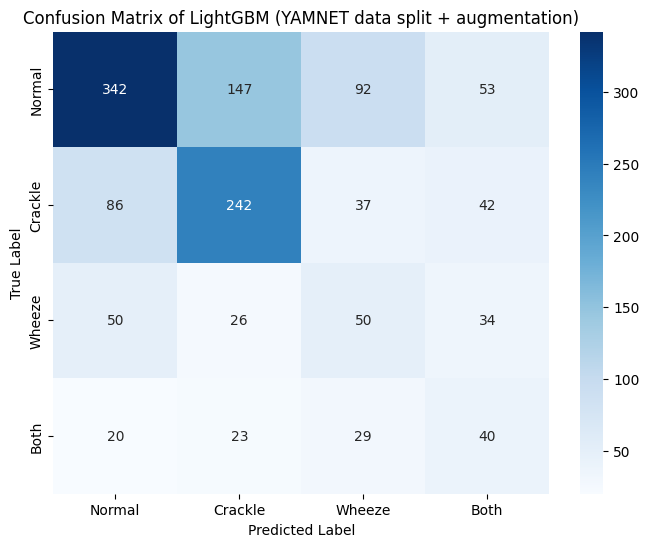

In [7]:
# CELL 7: Evaluation on test set
class_names = ['Normal', 'Crackle', 'Wheeze', 'Both']
y_pred = lgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("RESULTS")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print("-" * 40)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix of LightGBM (YAMNET data split + augmentation)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()